In [1]:
import math
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import colormaps as cm
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse.linalg import svds
import xarray as xr

from graphufs.datasets import Dataset
from graphufs.stacked_utils import get_channel_index
from graphcast.stacked_normalization import normalize
from graphcast.model_utils import stacked_to_dataset
from prototypes.ocn_only.emulator import OcnEvaluator

In [2]:
def load_model_inputs(config, category="validation", nsamples=-1):
    """Loads input data based on the model's configuration.
    Inputs:
        config: the model config
        data_type: training/validation (default=validation)

    Outputs:
        ds (xr.Dataset): the requested dataset 
    """
    
    # Setup
    emulator = OcnEvaluator(config["run"])
    ds_dir = f"{emulator.local_store_path}/{category}"

    # Compute logic
    if os.path.isdir(ds_dir):
        inputs = xr.open_zarr(f"{ds_dir}/inputs.zarr") # (sample, lat, lon, channels)
        return inputs.isel(sample=slice(None, nsamples))
    else:
        raise ValueError(f"{ds_dir} not found. Aborting...")
        sys.exit()

In [3]:
def normalize_inputs(config, inputs):
    """
    Normalizes the inputs using the model config's stored statistics.
    Inputs:
        config (dict): the model config
        inputs (xr.Dataset): the input dataset to normalize
    
    Outputs:
        normalized_inputs (xr.Dataset): normalized inputs
    """
    # Setup
    emulator = OcnEvaluator(config["run"])
    ds_dir = f"{emulator.local_store_path}/stacked-normalization/inputs"

    # mean/stddev
    ds_mean = xr.open_zarr(os.path.join(ds_dir, "mean_by_level.zarr"))
    ds_stddev = xr.open_zarr(os.path.join(ds_dir, "stddev_by_level.zarr"))
    
    # normalize
    mean = ds_mean["inputs"]
    stddev = ds_stddev["inputs"]
    normalized_inputs = (inputs["inputs"]-mean)/stddev
    
    return normalized_inputs

In [4]:
def condition_number_iter(X):
    """
    This function computes the condition number for a given dataset 
    using the iterative scipy.sparse.linalg.svds method assuming that 
    the dataset is large and a full SVD decomposition is diffucult. 
    Although the function assumes certain level of sparsity in the 
    dataset, which is not necessarily the case here, I'm not sure if 
    this is a problem. Note that ds must be normalized here.
    
    Inputs:
        X (np.ndarray): zarr input dataset (normalized)
    
    Outputs:
        cond_number (float32): the condition number of ds 
    """
    # Find the largest singular value (sigma_max)
    # We ask for the 1 largest magnitude ('LM') singular value.
    # svds returns u, s, vt. We only need s.
    try:
        _, s_max, _ = svds(X, k=1, which='LM')

        # Find the smallest singular value (sigma_min)
        # We ask for the 1 smallest magnitude ('SM') singular value.
        _, s_min, _ = svds(X, k=1, which='SM')

        # 3. Compute the condition number
        if s_min[0] > 0:
            cond_number = s_max[0] / s_min[0]
            print(f"Shape of data: {X.shape}")
            print(f"Largest singular value (σ_max): {s_max[0]:.2f}")
            print(f"Smallest singular value (σ_min): {s_min[0]:.2f}")
            print(f"Condition number (efficient method): {cond_number:.2f}")
            return cond_number
        else:
            print("Smallest singular value is zero. The matrix is singular.")

    except Exception as e:
        print(f"An error occurred during svds calculation: {e}")
        print("This can happen if k is too close to the matrix dimensions or with convergence issues.")
        
    return

In [5]:
def condition_number_svd(X, compute_uv=False):
    """
    Computes the condition number of a matrix using full SVD.

    Args:
        X (np.ndarray): The input data matrix (n_samples, n_features).
        compute_uv (bool): Whether to compute u and v matrices alongside
                           the singular values.

    Returns:
        U, s, V: All singular values (in s) and the left and right singular 
                 vectors (U and V, respectively).
        condition_number: The condition number of the matrix. Returns 
                          np.inf if the matrix is singular (smallest 
                          singular value is 0).
    """
    # Compute the singular values of the matrix X.
    # We set compute_uv=False because we only need the singular values (s),
    # not the U and Vh matrices, which saves computation.
    if compute_uv:
        U, s, V = np.linalg.svd(X, compute_uv=compute_uv)
    else:
        s = np.linalg.svd(X, compute_uv=compute_uv)

    # Find the largest (s_max) and smallest (s_min) singular values.
    s_max = np.max(s)
    tol = 1e-5
    s_min = np.min(s[s>tol])
    
    print(f"Largest singular value (σ_max): {s_max:.2f}")
    print(f"Smallest singular value (σ_min): {s_min:.2f}")

    # Compute the condition number.
    # Handle the case where s_min is zero to avoid division errors.
    if s_min == 0:
        print("Warning: Smallest singular value is zero. Matrix is singular.")
        return np.inf
    
    condition_number = s_max / s_min

    if compute_uv:
        return U, s, V, condition_number
    else:
        return s, condition_number

In [6]:
def cross_correlation(da: xr.DataArray,
                      dim: str = "channels",
                      spatial_avg: bool = True,
                      lat_dim: str = "lat",
                      lon_dim: str = "lon",
                      needs_standardization: bool = True
                     ) -> xr.DataArray:
    """
    Calculates the cross-correlation matrix for all pairs along dim.

    Args:
        da (xr.DataArray): The input DataArray, which should be loaded into memory.
                           ('sample', 'lat', 'lon', 'channels').
        dim (str): The dimension along which variables are defined (e.g., "channels").
        spatial_avg (bool): If True, spatially average the covariance/correlation.
        lat_dim (str): Name of the latitude dimension.
        lon_dim (str): Name of the longitude dimension.
        needs_standardization (bool): whether standardization is needed before computing
                                      correlation.

    Returns:
        xr.DataArray: A DataArray containing the full covariance or correlation matrix.
    """

    n_samples = da.sizes["sample"]

    statistic = "correlation"
    # First z-score the data and then compute the covariance of the result.

    # Calculate mean and sample standard deviation (with ddof=1).
    if needs_standardization:
        mean = da.mean(dim="sample", skipna=True).persist()
        std = da.std(dim="sample", skipna=True, ddof=1).persist()
        #epsilon = 1e-12 # when turned on, this is leading inconsistencies,
                         # menifested by the diag entries of corr not eq 1. 

        # Z-score the data.
        da_zscored = (da - mean) / std

    else:
        da_zscored = da
        
    # The correlation is the covariance of the z-scored data.
    da1 = da_zscored.rename({dim: f"{dim}_x"})
    da2 = da_zscored.rename({dim: f"{dim}_y"})

    # The dot product of z-scored data, divided by (n-1), is the correlation map.
    corr_map = xr.dot(da1, da2, dims="sample") / (n_samples - 1)

    # 4. Average the correlation map over spatial dimensions.
    out_matrix = corr_map #.mean(["lat", "lon"], skipna=True)

    if spatial_avg:
        out_matrix = out_matrix.mean([lat_dim, lon_dim], skipna=True)

    out_matrix.attrs = {"description": f"tendency {statistic}"}

    return out_matrix

In [7]:
def load_model_prediction(config, eval_dates):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    if pred_prefix == "persistence":
        num_missing_samples = config["num_missing_samples"] if config["num_missing_samples"] else 0
        return persistence_fcast(
            config["model_type"], config["run"], eval_dates, 
            num_missing_samples=num_missing_samples,
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "climatology":
        return climatology_fcast(
            config["model_type"], config["run"], eval_dates, 
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "graphufs":
        infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
        fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
        model_pred = xr.open_zarr(fname)
        return model_pred.sel(time=slice(eval_dates[0], eval_dates[1]))
    
    else:
        raise ValueError(f"Unknown model type: {pred_prefix}")

In [8]:
def calculate_error_and_forecasts_for_model(model_pred, ref_truth):
    """
    Calculates error and stores error and forecast for a given model 
    against a truth reference.
    """
    # Create a land/sea mask based on the salinity field at the first time step
    mask = xr.where(ref_truth.so.isel(time=0, lead_time=0) == 0, 0, 1)
    
    error_vars = {}
    forecasts = {}

    for var in model_pred.data_vars:
        # Determine the correct mask to use for this variable (with or without depth)
        current_mask = mask if "z_l" in model_pred[var].dims else mask.isel(z_l=0)
        
        # Compute error and apply mask
        error = (model_pred[var] - ref_truth[var]) * current_mask
        
        error_vars[var] = error
        forecasts[var] = model_pred[var]*current_mask
        
    return error_vars, forecasts

In [9]:
def persistence_fcast(model_type:str, prototype:str, eval_dates:list[str], num_missing_samples:int, fcast_nhours="240h"):

    #### SETUP ####
    emulator = OcnEvaluator(prototype)
    preserved_dims = ("batch", "lat", "lon")

    #### LOAD AND PREPARE THE STACKED DATA ####
    # read in the validation data
    valid_dir = f"{emulator.local_store_path}/validation"
    validation_inputs = xr.open_zarr(f"{valid_dir}/inputs.zarr")["inputs"] # (sample, lat, lon, channels)

    # Calculate the date ranges and find the integer indices for slicing
    validation_datetime = pd.date_range(
        start=pd.to_datetime(emulator.validation_dates[0]),
        end=(pd.to_datetime(emulator.validation_dates[1]) - 
             pd.Timedelta(emulator.delta_t_model)) - num_missing_samples*pd.Timedelta(emulator.delta_t_data),
        freq=pd.Timedelta(emulator.delta_t_data),
        inclusive="both",
    )
    
    # check the length of the validation dataset = validation datetime
    assert len(validation_datetime)==validation_inputs.sizes["sample"], \
    f"Error: Length of the time stamp vector and validation inputs did not match: {len(validation_datetime)}, {validation_inputs.sizes['sample']}"

    idx_start = validation_datetime.get_loc(pd.to_datetime(eval_dates[0]))
    idx_end = validation_datetime.get_loc(pd.to_datetime(eval_dates[1]))

    # Select the evaluation data and rename 'sample' to 'batch' for consistency
    eval_inputs = validation_inputs.sel(sample=slice(idx_start, idx_end, emulator.sample_stride)
    ).rename({"sample": "batch"}) # (batch=292, lat, lon, channels)

    # get the datetime vector corresponding to the evaluation data
    eval_datetime = pd.date_range(
        start=pd.to_datetime(eval_dates[0]),
        end=pd.to_datetime(eval_dates[1]),
        freq=pd.Timedelta(emulator.delta_t_data)*emulator.sample_stride,
        inclusive="both",
    )
    
    # assert the lengths of the eval datetime vector and the eval dataset
    assert len(eval_datetime)==eval_inputs.sizes["batch"], \
    f"Error: Length of the eval datetime vector and eval inputs did not match:" \
    f"{len(eval_datetime)}, {eval_inputs.sizes['batch']}"

    #### PREPARE THE TEMPLATE DATASET ####
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)
    meta_xinputs = get_channel_index(xinputs)

    for variable in xinputs.data_vars:
        dims_to_ensure = preserved_dims #tuple(d for d in preserved_dims if d != "batch")
        dims_not_present = [d for d in dims_to_ensure if d not in xinputs[variable].dims]
        for dimen in dims_not_present:
            xinputs[variable] = xinputs[variable].expand_dims(dim={dimen:eval_inputs.coords[dimen]})
        # make sure that the batch dimension has the same size in both datasets. Actually all
        # preserved dims must have the same size in both.
        if xinputs.sizes["batch"] != eval_inputs.sizes["batch"]:
            xinputs = xinputs.reindex({"batch":eval_inputs.coords["batch"]}, method="pad")
        xinputs[variable] = xinputs[variable].transpose("batch", ..., "lat", "lon")

    #### UNSTACK VALIDATION DATA ####
    # Only consider the input channels, not forcing. Note that xinputs would not have
    # forcing channels appended at the end. Just choose the inputs because the mapping
    # is only for inputs and this is what we need essentially.
    eval_inputs = eval_inputs.isel(channels=slice(None, len(meta_xinputs)))

    # Unstack the data by passing the underlying .variable object
    eval_inputs_unstacked = stacked_to_dataset(eval_inputs.variable, 
                                               xinputs, preserved_dims=preserved_dims)
    
    # now return the persistence in the same form as targets
    ds_persistence_fcast = xr.Dataset()
    
    # lead_time dimension
    start = emulator.delta_t_model                        # Start at delta_t_model duration
    end = pd.Timedelta(int(fcast_nhours[:-1]), unit="h")  # End at nhours duration

    # Generate the TimedeltaIndex 
    intervals = pd.timedelta_range(start=start, end=end, freq=emulator.delta_t_model)

    for variable in xtargets.data_vars:
        var = eval_inputs_unstacked[variable].isel(time=-1, drop=True)
        var = var.rename(batch="time").assign_coords(time=eval_datetime)
        var = var.expand_dims(dim={"lead_time":intervals})
        ds_persistence_fcast[variable] = var.transpose("time", ..., "lead_time", "lat", "lon")
    
    return ds_persistence_fcast

## Config and Computation

In [10]:
# ---- Config ----
TRUTHS = ["Replay"]
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"
PLOT_METRIC = "RMSE"

MODELS_CONFIG = [
    {
        "name": "Emulator-24h-1IC-coarseTop (Baseline)",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-2IC-coarseTop",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R6",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-2ic-coarseTop"
    },
    {
        "name": "Emulator-6h-1IC-coarseTop",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R4",
        "expt": "T3M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay",
        "timestep": "6h",
        "duration": "240h",
        "description": "6hour-1ic-coarseTop"
    },
    {
        "name": "Emulator-24h-1IC-fineTop",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R10",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "4320h",
        "description": "24hour-1ic-fineTop"
    },
    {
        "name": "Persistence-24h",
        "type": "persistence",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "",
        "pred_prefix": "persistence",
        "timestep": "24h",
        "duration": "240h",
        "description": "persistence",
        "num_missing_samples": 3,
    }
]

## Condition Number

In [11]:
# ---- The Main Computation Block ----
all_cond_number = {}
compute_uv = False
nsamples = 300
compute_svd_of_correlation = False

# Main loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"\nProcessing Model: {model_name}")

    # Load the model input data
    model_inputs = load_model_inputs(model_config, nsamples=nsamples)
    
    # normalize the inputs
    print("Normalizing Input Dataset ... ")
    standardized_x = normalize_inputs(model_config, model_inputs)
    print("Normalization done!!!")

    if compute_svd_of_correlation:
        # compute the correlation matrix
        print("Computing the correlation matrix ... ")
        correlation_x = cross_correlation(standardized_x, needs_standardization=False).compute()
        print("Correlation computation done !!!")
        print("Correlation Matrix:", correlation_x)

        print("Computing condition number of the correlation matrix...")
        if compute_uv:
            U, all_cond_number[model_name], V, cond_num = condition_number_svd(correlation_x, compute_uv=True)
        else:
            all_cond_number[model_name], cond_num = condition_number_svd(correlation_x, compute_uv=False)
    
    else:
        # compute the condition number
        print("Computing condition number ...")
        da = standardized_x
        data = da.values.reshape((da.sizes["sample"]*da.sizes["lat"]*da.sizes["lon"], 
                                  da.sizes["channels"]))
        if compute_uv:
            U, all_cond_number[model_name], V, cond_num = condition_number_svd(data, compute_uv=True)
        else:
            all_cond_number[model_name], cond_num = condition_number_svd(data, compute_uv=False)
        
    #print("last two columns of V:", V[:,-2:])
    print("singular values spectrum:", all_cond_number[model_name])
    print("Condition number = ", cond_num)


Processing Model: Emulator-24h-1IC-coarseTop (Baseline)


ValueError: /pscratch/sd/n/nagarwal/ocn-only/R5/validation not found. Aborting...

## Store Forecasts and SSH RMSE

In [12]:
# Initialize a dictionary to store the results
all_errors = {}
all_forecasts = {}
    
# Main loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"\nProcessing Model: {model_name}")

    all_forecasts[model_name] = {}
    all_errors[model_name] = {}
        
    # Load the model prediction data once
    model_pred = load_model_prediction(model_config, EVALUATION_DATES)
        
    # Loop over the truth references for this model
    for truth_name in TRUTHS:
        print(f"Comparing against truth: {truth_name} ...")
            
        # Construct the path to the truth data
        if model_config["type"] in ["persistence", "climatology"]:
            # Logic to find the corresponding replay file for baselines
            run = "R5" if model_config['timestep'] == "24h" else "R4"
            expt = "T1M" if model_config['timestep'] == "24h" else "T3M"
            duration = "240h"
            location = os.path.join(SCRATCH_DIR, model_config["model_type"], run, f"inference_{expt}/validation/")
            fname = f"{location}/replay.{duration}.zarr"
        else:
            infer_dir = f"inference_{model_config['expt']}" if model_config["expt"] else "inference"
            location = os.path.join(SCRATCH_DIR, model_config['model_type'], model_config['run'], f"{infer_dir}/validation/")
            fname = f"{location}/{truth_name.lower()}.{model_config['duration']}.zarr"

        ref_truth = xr.open_zarr(fname)
            
        # Calculate all metrics for this model against this truth
        err, forecasts = calculate_error_and_forecasts_for_model(model_pred, ref_truth)
            
        # Store results
        all_errors[model_name][truth_name] = err
        all_forecasts[model_name][truth_name] = forecasts

print("\n --- Metric calculation complete!! ---")


Processing Model: Emulator-24h-1IC-coarseTop (Baseline)
Comparing against truth: Replay ...

Processing Model: Emulator-24h-2IC-coarseTop
Comparing against truth: Replay ...

Processing Model: Emulator-6h-1IC-coarseTop
Comparing against truth: Replay ...

Processing Model: Emulator-24h-1IC-fineTop
Comparing against truth: Replay ...

Processing Model: Persistence-24h
Comparing against truth: Replay ...

 --- Metric calculation complete!! ---


## Plotting

In [13]:
def plot_singular_values_on_ax(ax, sv_dict):
    """
    Adapted to plot on a specific axis 'ax' instead of creating a new figure.
    """
    # Loop through each matrix's singular values
    for name, values in sv_dict.items():
        if "persistence" in name.lower():
            continue
            
        # Sort values in descending order
        sorted_values = sorted(values, reverse=True)
        
        # Create index (1-based)
        indices = np.arange(1, len(sorted_values) + 1)
        
        # Plot
        ax.plot(indices, sorted_values, marker='.', linestyle='-', label=name, alpha=0.8)

    # Formatting
    ax.set_yscale('log')
    ax.set_xlabel('Singular Value Index (k)', fontsize=12)
    ax.set_ylabel('Magnitude (log)', fontsize=12)
    ax.set_title('Condition Number Spectrum', fontsize=12)
    ax.legend(title='Models', fontsize=12)
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.xaxis.get_major_locator().set_params(integer=True)

In [14]:
def plot_error_vs_leadtime_seaborn(
    ax,
    da: xr.DataArray,
    var_name: str = None,
    unit: str = None,
    timestep: str = "6h",
    forecast_days: int = 10,
    label: str = "",
    ytitle: str = "RMSE",
    vmin: float = None,
    vmax: float = None,
    show_title: bool = True,
):
    """
    Plot RMSE vs lead_time using Seaborn with a 95% CI over the init time.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with at dimensions ("init_time", "lead_time").
    - var_name: name of the variable
    - unit: unit of the variable
    - timestep: Time step of the forecast (e.g., "6h", "12h").
    - forecast_days: Number of forecast days to consider.
    - label: label to use in legend
    - vmin, vmax: y-axis bounds for RMSE
    - show_title: whether to display the plot title
    """
    # --- 1. Data Preparation ---
    # Convert lead time from timedelta to hours
    lead_time_hours = da['lead_time'].values / np.timedelta64(1, 'h')
    
    # Convert the xarray.DataArray to a long-form pandas.DataFrame
    df = da.to_dataframe(name='rmse').reset_index()
    # Add a column for lead time in hours for easier filtering
    df['lead_time_hours'] = df['lead_time'].dt.total_seconds() / 3600

    # --- 2. Subsampling Logic ---
    # Calculate the number of forecast steps per day
    timestep_hours = int(timestep[:-1])
    steps_per_day = int(24 / timestep_hours)

    # Create a list of the lead time hours that correspond to the end of each day
    # e.g., for 6h steps: 24h, 48h, 72h...
    hours_to_plot = [d * 24 for d in range(1, forecast_days + 1)]
    
    # Filter the DataFrame to only include these specific lead times
    df_subsampled = df[df['lead_time_hours'].isin(hours_to_plot)].copy()
    
    # Add a 'lead_time_days' column for plotting
    df_subsampled['lead_time_days'] = df_subsampled['lead_time_hours'] / 24

    # --- 3. Plotting with Seaborn ---
    # Use the subsampled DataFrame. Add markers to make the points clear.
    sns.lineplot(
        data=df_subsampled,
        x='lead_time_days',
        y='rmse',
        ax=ax,
        label=label,
        linewidth=2,
        errorbar=("ci", 95),
        marker='o', # Added a marker to highlight the daily points
        markersize=8
    )
    
    # --- 4. Customizing the Plot ---
    # vmin/vmax
    if vmin is not None and vmax is not None:
        ax.set_ylim(vmin, vmax)

    # axis labels
    xlabel = "Forecast Lead Time [days]"
    ylabel = f"{ytitle} [{unit}]" if unit else ytitle
    #if apply_latitude_weighting:
    #    ylabel = f"LW-{ylabel}"
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

    # axis ticks
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    # Ensure ticks are integers from 1 to forecast_days
    ax.set_xticks(np.arange(1, forecast_days + 1))

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # title
    if show_title:
        ax.set_title(f"{var_name}", fontsize=12)
        
    return ax


In [15]:
# ==========================================
# MAIN PLOTTING DASHBOARD
# ==========================================
def plot_model_dashboard(models_config, all_forecasts, all_sq_errors, 
                         sv_dict, forecast_days=10, truth="Replay",
                         var_name="SSH", unit="m", lat_min=-10, lat_max=25, lon_min=240,
                         lon_max=320, save_plot=False):
    
    # Setup Figure and GridSpec
    # ----------------------------
    # We need a 2-row layout. 
    # Row 1: 3 columns (Forecasts)
    # Row 2: 2 columns (Scree Plot + RMSE line)
    # We use a grid with 6 columns total to make the math easy.
    # Row 1: Each plot takes 2 columns
    # Row 2: Each plot takes 3 columns
    
    fig = plt.figure(figsize=(24, 12))
    gs = gridspec.GridSpec(2, 6, height_ratios=[1, 0.8], hspace=0.3, wspace=0.5)

    # Define the geographic bounds
    lat_slice = slice(lat_max, lat_min)
    lon_slice = slice(lon_min, lon_max) # 40W to 100W 
    extent = [lon_min, lon_max, lat_min, lat_max] # For Cartopy [LonMin, LonMax, LatMin, LatMax]

    # Row 1: Forecast Error Snapshots (Day 10)
    # -------------------------------------
    target_lead = pd.Timedelta(forecast_days, unit='D')
    
    for i, model_cfg in enumerate(MODELS_CONFIG):
        name = model_cfg['name']
        
        # Create Subplot with Projection
        ax = fig.add_subplot(gs[0, 2*i : 2*i+2], projection=ccrs.PlateCarree())
        
        # 1. Get Data
        # Use .sel with method='nearest' to handle 6h vs 24h timesteps automatically
        ds = all_errors[name][truth][var_name].isel(time=0).sel(lead_time=target_lead, method="nearest")
        
        # 2. Slice Region
        ds_reg = ds.sel(lat=lat_slice, lon=lon_slice)
        
        # 3. Plot
        mesh = ax.pcolormesh(
            ds_reg.lon, ds_reg.lat, ds_reg.values.squeeze(),
            transform=ccrs.PlateCarree(),
            cmap=cm.BlueWhiteOrangeRed, 
            shading='auto',
            vmin=-0.2,
            vmax=0.2,
        )
        
        # 4. Aesthetics
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.coastlines()
        ax.add_feature(cfeature.LAND, facecolor='black')
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.set_title(f"{name}\nDay 10 Forecast minus Truth ({var_name} [{unit}])", fontsize=11)
        
        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        
        # Add colorbar for the last plot (or individual, here we do one per plot for safety)
        plt.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)

    # Row 2, Panel 1: Condition Number (Scree Plot)
    # -------------------------------------------------------
    ax_cond = fig.add_subplot(gs[1, 0:3]) # Takes first 3 cols of row 2
    
    # call the helper function
    if sv_dict:
        plot_singular_values_on_ax(ax_cond, sv_dict)
    else:
        ax_cond.text(0.5, 0.5, "No Singular Value Data Provided", ha='center')

    # Row 2, Panel 2: 10-day SSH RMSE Comparison
    # ---------------------------------------------
    ax_rmse = fig.add_subplot(gs[1, 3:6]) # Takes last 3 cols of row 2
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Matplotlib defaults
    
    for model_cfg in models_config:
        name = model_cfg['name']
        
        # Access SSH Error
        # Note: Ensure 'SSH' key exists in all_sq_errors
        if 'SSH' in all_sq_errors[name][truth]:
            sq_err_da = np.square(all_errors[name][truth]['SSH'])
            
            # Compute RMSE (Root Mean of Squared Errors)
            # Global spatial mean (weighted if needed, but simple mean for now)
            mse = sq_err_da.mean(dim=("time","lat","lon"))
            rmse = np.sqrt(mse)
            
            # Plot RMSE and its CI
            plot_error_vs_leadtime_seaborn(
                ax_rmse, 
                rmse, 
                var_name='SSH', 
                unit='m',
                timestep=model_cfg["timestep"],
                forecast_days=forecast_days,
                label=model_cfg["name"],
                ytitle="RMSE",
                vmin=0,
                vmax=0.25,
            )
            
        else:
            raise KeyError(f'SSH nor found in {name}')

    if save_plot:
        figname = f"figure4.png"
        plt.savefig(f"./figures/{figname}", dpi=300, bbox_inches='tight')
        
    plt.show()

In [16]:
# ==========================================
# PLOTTING DASHBOARD, a 3x2 panel
# ==========================================
def _get_next_row_col_idx(row_idx, col_idx, max_panels_per_row):
    """
    Computes and returns row/col indices using their current values
    and max panels in a single row.
    """
    if col_idx == max_panels_per_row-1:
        row_idx += 1; col_idx=0
    else:
        col_idx += 1

    return row_idx, col_idx

def plot_model_dashboard_3x2(models_config, all_forecasts, all_sq_errors, 
                             sv_dict, forecast_days=10, truth="Replay",
                             var_name="SSH", unit="m", lat_min=-10, lat_max=25, lon_min=240,
                             lon_max=320, save_plot=False):
    
    # Initialize the figure
    tot_panels = len(MODELS_CONFIG) + 2 # 2 more panels added: one for condition number and
                                        # another for the SSH RMSE line plot
    max_panels_per_row = 2
    num_rows = tot_panels // max_panels_per_row
    if not tot_panels % max_panels_per_row == 0:
        num_rows +=1 
    
    fig = plt.figure(figsize=(num_rows*8, max_panels_per_row*9))

    # Plot 10-day spatial RMSE map for all models in the MODELS_CONFIG
    # -------------------------------------
    gridspec_col_div = 10
    gs = gridspec.GridSpec(num_rows, gridspec_col_div*max_panels_per_row,
                          hspace=0.3, wspace=0.25)

    # Define the geographic bounds
    lat_slice = slice(lat_max, lat_min)
    lon_slice = slice(lon_min, lon_max) # 40W to 100W 
    extent = [lon_min, lon_max, lat_min, lat_max] # For Cartopy [LonMin, LonMax, LatMin, LatMax]

    target_lead = pd.Timedelta(forecast_days, unit='D')
    
    for i, model_cfg in enumerate(MODELS_CONFIG):
        row_idx = i // max_panels_per_row
        col_idx = i % max_panels_per_row
        
        name = model_cfg['name']
        
        # Create Subplot with Projection
        if i == len(MODELS_CONFIG)-1 and max_panels_per_row==2 and col_idx==0:
            mid_of_col = 0#gridspec_col_div // 2
            ax = fig.add_subplot(gs[row_idx, mid_of_col:mid_of_col+gridspec_col_div], 
                                 projection=ccrs.PlateCarree())
        else:
            ax = fig.add_subplot(gs[row_idx, col_idx*gridspec_col_div:(col_idx+1)*gridspec_col_div-1], 
                                 projection=ccrs.PlateCarree())
        
        # 1. Get Data
        # Use .sel with method='nearest' to handle 6h vs 24h timesteps automatically
        ds = all_errors[name][truth][var_name].isel(time=0).sel(lead_time=target_lead, method="nearest")
        
        # 2. Slice Region
        ds_reg = ds.sel(lat=lat_slice, lon=lon_slice)
        
        # 3. Plot
        mesh = ax.pcolormesh(
            ds_reg.lon, ds_reg.lat, ds_reg.values.squeeze(),
            transform=ccrs.PlateCarree(),
            cmap=cm.BlueWhiteOrangeRed, 
            shading='auto',
            vmin=-0.2,
            vmax=0.2,
        )
        
        # 4. Aesthetics
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='black', zorder=2)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.set_title(f"{name}\nDay 10 Forecast minus Truth ({var_name} [{unit}])", fontsize=11)
        
        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        
        # Add colorbar for the last plot (or individual, here we do one per plot for safety)
        plt.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)

    # Condition Number (Scurry/Scree Plot)
    # -------------------------------------------------------
    # We want this plot as the first plot of the next row, so the indices can be fixed manually
    row_idx += 1; col_idx = 0
    ax_cond = fig.add_subplot(gs[row_idx, col_idx*gridspec_col_div:(col_idx+1)*gridspec_col_div-1]) 
    
    # call the helper function
    if sv_dict:
        plot_singular_values_on_ax(ax_cond, sv_dict)
    else:
        ax_cond.text(0.5, 0.5, "No Singular Value Data Provided", ha='center')

    # 10-day SSH RMSE Comparison
    # ---------------------------------------------
    row_idx, col_idx = _get_next_row_col_idx(row_idx, col_idx, max_panels_per_row)
    ax_rmse = fig.add_subplot(gs[row_idx, col_idx*gridspec_col_div:(col_idx+1)*gridspec_col_div-1])
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Matplotlib defaults
    
    for model_cfg in models_config:
        name = model_cfg['name']
        
        # Access SSH Error
        # Note: Ensure 'SSH' key exists in all_sq_errors
        if 'SSH' in all_sq_errors[name][truth]:
            sq_err_da = np.square(all_errors[name][truth]['SSH'])
            
            # Compute RMSE (Root Mean of Squared Errors)
            # Global spatial mean (weighted if needed, but simple mean for now)
            mse = sq_err_da.mean(dim=("time","lat","lon"))
            rmse = np.sqrt(mse)
            
            # Plot RMSE and its CI
            plot_error_vs_leadtime_seaborn(
                ax_rmse, 
                rmse, 
                var_name='SSH', 
                unit='m',
                timestep=model_cfg["timestep"],
                forecast_days=forecast_days,
                label=model_cfg["name"],
                ytitle="RMSE",
                vmin=0,
                vmax=0.25,
            )
            
        else:
            raise KeyError(f'SSH nor found in {name}')
    
    if save_plot:
        figname = f"figure4.png"
        plt.savefig(f"./figures/{figname}", dpi=300, bbox_inches='tight')
        
    plt.show()

In [39]:
def _get_next_row_col_idx(row_idx, col_idx, max_panels_per_row):
    """
    Computes and returns row/col indices using their current values
    and max panels in a single row.
    """
    if col_idx == max_panels_per_row - 1:
        row_idx += 1
        col_idx = 0
    else:
        col_idx += 1
    return row_idx, col_idx

def plot_model_dashboard_multipanel(models_config, all_forecasts, all_sq_errors, 
                                    sv_dict, forecast_days=10, truth="Replay",
                                    var_name="SSH", unit="m", lat_min=-10, lat_max=25, lon_min=240,
                                    lon_max=320, save_plot=False):
    
    # Calculate layout dynamically
    num_spatial_maps = len(models_config)
    num_line_plots = 2  # condition number + RMSE
    max_panels_per_row = 2
    
    # Calculate rows needed for spatial maps
    spatial_rows = (num_spatial_maps + max_panels_per_row - 1) // max_panels_per_row
    
    # Add one more row for line plots
    total_rows = spatial_rows + 1
    
    # Figure size adapts to number of rows
    fig = plt.figure(figsize=(20, total_rows * 5))

    # Use simple GridSpec with proper spacing
    gs = gridspec.GridSpec(total_rows, max_panels_per_row, 
                           figure=fig,
                           hspace=0.3,
                           wspace=0.25)

    # Define the geographic bounds
    lat_slice = slice(lat_max, lat_min)
    lon_slice = slice(lon_min, lon_max)
    extent = [lon_min, lon_max, lat_min, lat_max]

    target_lead = pd.Timedelta(forecast_days, unit='D')
    
    # Plot all spatial maps
    for i, model_cfg in enumerate(models_config):
        name = model_cfg['name']
        
        row_idx = i // max_panels_per_row
        col_idx = i % max_panels_per_row
        
        # Check if this is the last map and it's alone in its row (odd number of maps)
        is_last_map = (i == num_spatial_maps - 1)
        is_alone_in_row = (num_spatial_maps % max_panels_per_row == 1)
        
        if is_last_map and is_alone_in_row:
            # Center the last map by using a custom position
            # Get the position of both columns and create a centered subplot
            gs_temp = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[row_idx, :], wspace=0.25)
            ax = fig.add_subplot(gs_temp[0, 1:3], projection=ccrs.PlateCarree())
        else:
            # Regular positioning
            ax = fig.add_subplot(gs[row_idx, col_idx], projection=ccrs.PlateCarree())
        
        # 1. Get Data
        ds = all_errors[name][truth][var_name].isel(time=0).sel(lead_time=target_lead, method="nearest")
        
        # 2. Slice Region
        ds_reg = ds.sel(lat=lat_slice, lon=lon_slice)
        
        # 3. Plot using xarray's pcolormesh (handles colorbar extend automatically)
        mesh = ds_reg.plot.pcolormesh(
            ax=ax,
            x='lon',
            y='lat',
            transform=ccrs.PlateCarree(),
            cmap=cm.BlueWhiteOrangeRed,
            vmin=-0.2,
            vmax=0.2,
            add_colorbar=True,
            cbar_kwargs={'orientation': 'vertical', 'fraction': 0.046, 'pad': 0.04},
            zorder=1
        )
        
        # 4. Aesthetics
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='black', zorder=2)
        #ax.add_feature(cfeature.BORDERS, linestyle=':', zorder=3)
        ax.set_title(f"{name}\nDay {forecast_days} Forecast minus Truth ({var_name} [{unit}])", 
                     fontsize=12,)
        
        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        
    # Last row: Line plots
    line_plot_row = spatial_rows
    
    # Condition Number (Scurry/Scree Plot)
    ax_cond = fig.add_subplot(gs[line_plot_row, 0]) 
    
    if sv_dict:
        plot_singular_values_on_ax(ax_cond, sv_dict)
    else:
        ax_cond.text(0.5, 0.5, "No Singular Value Data Provided", ha='center', va='center')

    # 10-day SSH RMSE Comparison
    ax_rmse = fig.add_subplot(gs[line_plot_row, 1])
    
    for model_cfg in models_config:
        name = model_cfg['name']
        
        # Access SSH Error
        if 'SSH' in all_sq_errors[name][truth]:
            sq_err_da = np.square(all_errors[name][truth]['SSH'])
            
            # Compute RMSE
            mse = sq_err_da.mean(dim=("time", "lat", "lon"))
            rmse = np.sqrt(mse)
            
            # Plot RMSE
            plot_error_vs_leadtime_seaborn(
                ax_rmse, 
                rmse, 
                var_name='SSH', 
                unit='m',
                timestep=model_cfg["timestep"],
                forecast_days=forecast_days,
                label=model_cfg["name"],
                ytitle="RMSE",
                vmin=0,
                vmax=0.25,
            )
        else:
            raise KeyError(f'SSH not found in {name}')

    #plt.tight_layout()
    
    if save_plot:
        figname = f"figure4.png"
        plt.savefig(f"./figures/{figname}", dpi=300, bbox_inches='tight')
        
    plt.show()

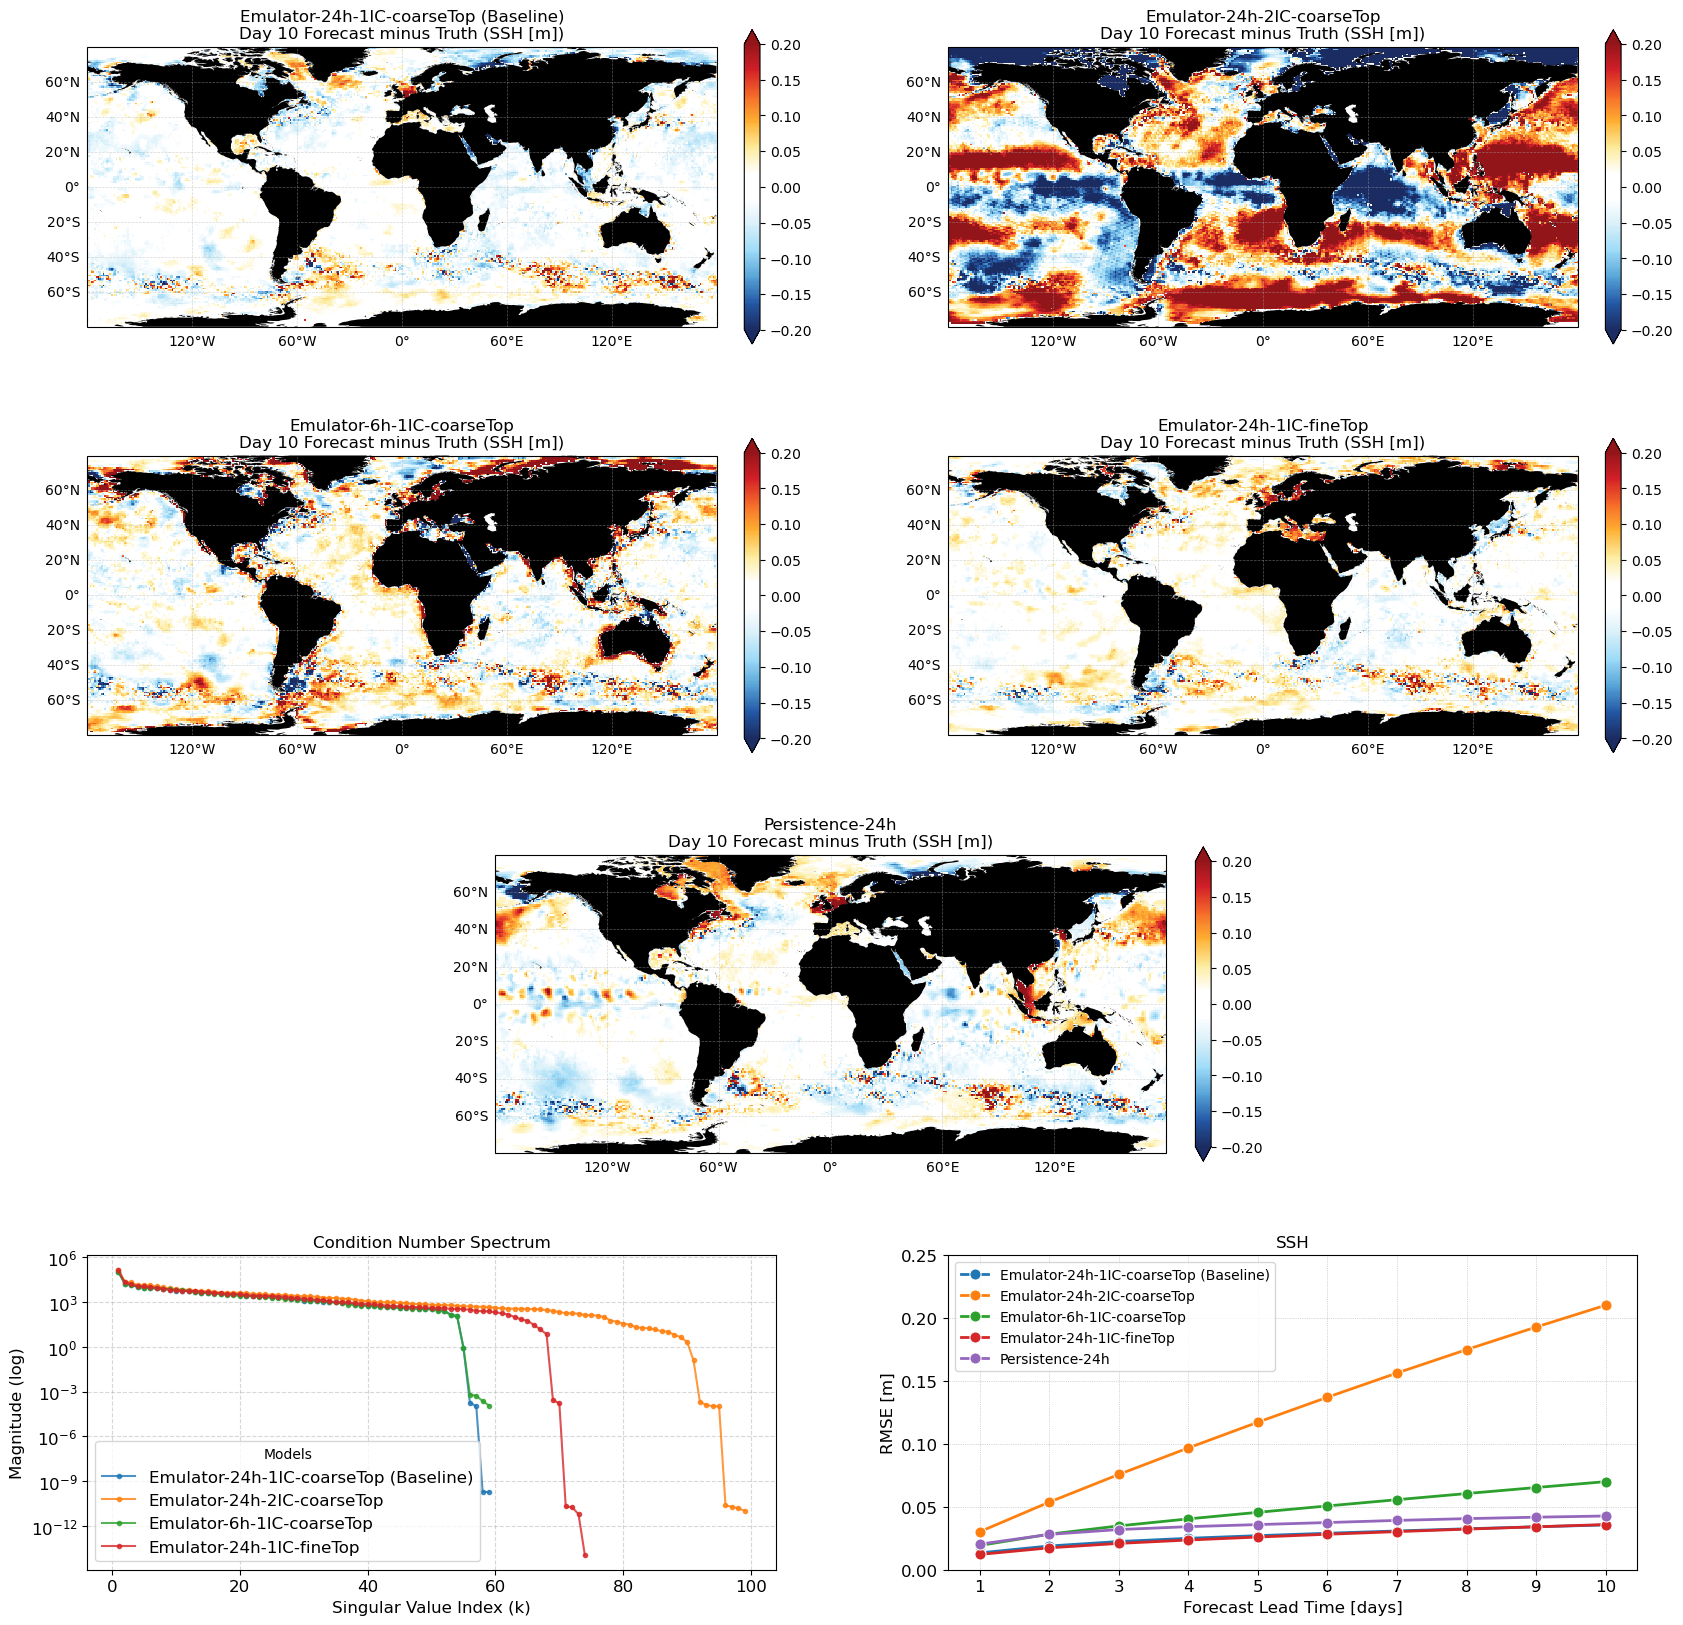

In [40]:
# Plot using the above utility function
lat_min=-80; lat_max=80
lon_min=0; lon_max=359.9
forecast_lead = "10 days"
plot_model_dashboard_multipanel(MODELS_CONFIG, all_forecasts, all_errors, all_cond_number, 
                                var_name="SSH", unit="m", lat_min=lat_min, lat_max=lat_max,
                                lon_min=lon_min, lon_max=lon_max, save_plot=False)